Existing gauges per cluster:
 cluster
0    1
1    0
2    1
3    0
4    0
5    0
6    1
7    3
8    2
9    0
Name: count, dtype: int64
Target quota per cluster:
 0    2.58
1    0.77
2    0.85
3    2.53
4    2.57
5    1.60
6    1.45
7    3.57
8    0.90
9    1.18
Name: count, dtype: float64
New gauges to place per cluster:
 0    2
1    1
2    0
3    2
4    2
5    2
6    0
7    0
8    0
9    1
dtype: int64
   cluster   row   col              x              y         dem      slope
0        0  2370  1545  289252.500033  283722.499885  312.519989  10.401600
1        0  2493  2141  292232.500032  283107.499885  312.500000  10.396373
2        1  3373  4025  301652.500030  278707.499886  443.200012  22.330967
3        3  3748  2391  293482.500032  276832.499887  401.179993  11.459283
4        3   586   746  285257.500034  292642.499882  401.160004  11.472264
5        4  1748  1322  288137.500034  286832.499884  430.019989   4.933070
6        4  2878  1654  289797.500033  281182.499886  430.0700

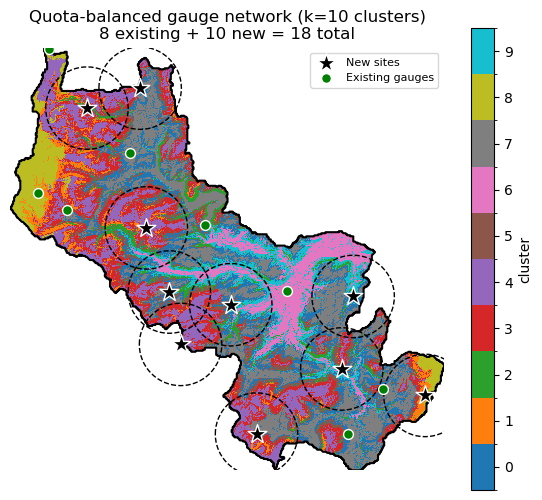

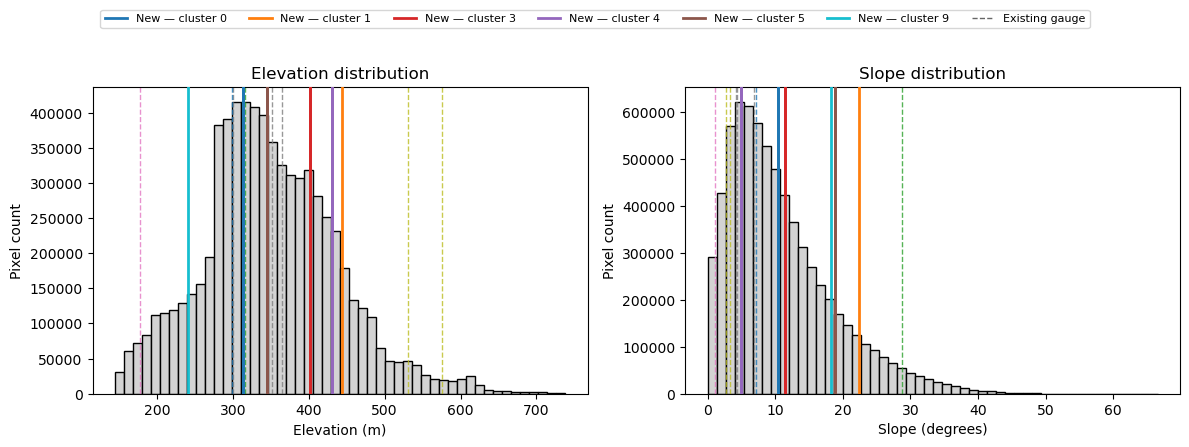

In [23]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import importlib
import rioxarray
import rasterio
import matplotlib.colors as mcolors
import matplotlib
import random
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

data_dir = "/scratch/hydro4/users/kv25483/FDRI/Rain_gauge_optimisation/Data/"
catchment_Dolwen = gpd.read_file(data_dir + "54080/54080.shp")

import functions
importlib.reload(functions)
from functions import *   # expects: is_feasible, greedy_selection, shuffle_greedy, score

# --------------------------------------------------
# Load rain gauge metadata (existing network)
# --------------------------------------------------
rain_meta_cmd = pd.read_csv(data_dir + "rain_meta_for_CMD.csv")
rain_meta_sf = gpd.GeoDataFrame( rain_meta_cmd, geometry=gpd.points_from_xy(rain_meta_cmd["x_2"], rain_meta_cmd["y_2"]),
    crs="EPSG:27700")

rainfall_gdf_merged = gpd.read_file(data_dir + "Derived/rainfall_gdf_merged.gpkg")

# --------------------------------------------------
# 1. Load DEM
# --------------------------------------------------
dem_path = data_dir + "dem_Dolwen.tif"
with rioxarray.open_rasterio(dem_path, masked=True) as dem_rx:
    dem = dem_rx.squeeze()
    dem_arr = dem.values.astype(float)
    transform = dem.rio.transform()

dx = transform.a
dy = -transform.e

# --------------------------------------------------
# 2. Slope + aspect
# --------------------------------------------------
dz_dy, dz_dx = np.gradient(dem_arr, dy, dx)
slope_arr = np.degrees(np.arctan(np.sqrt(dz_dx**2 + dz_dy**2)))
aspect_arr = np.degrees(np.arctan2(-dz_dx, dz_dy))
aspect_arr = np.where(aspect_arr < 0, 360 + aspect_arr, aspect_arr)

aspect_rad = np.deg2rad(aspect_arr)
aspect_sin = np.sin(aspect_rad)
aspect_cos = np.cos(aspect_rad)

# --------------------------------------------------
# 3. Valid pixel mask + feature matrix
#    (using dem + slope only, matching your latest script;
#     add aspect_sin/aspect_cos back in here AND in gauge_features
#     below if you want aspect included)
# --------------------------------------------------
valid_mask = ~np.isnan(dem_arr) & ~np.isnan(slope_arr) & ~np.isnan(aspect_arr)

features = np.column_stack([dem_arr[valid_mask],
                            slope_arr[valid_mask],
#                            aspect_sin[valid_mask],
#                          aspect_cos[valid_mask],
                           ])

# --------------------------------------------------
# 4. Scale + cluster
# --------------------------------------------------
scaler = StandardScaler()
X = scaler.fit_transform(features)

k = 10
kmeans = KMeans(n_clusters=k, random_state=0)
labels = kmeans.fit_predict(X)

# --------------------------------------------------
# 5. Reshape labels back into 2D grid
# --------------------------------------------------
label_grid = np.full(dem_arr.shape, np.nan)
label_grid[valid_mask] = labels

label_xr = dem.copy()
label_xr.data = label_grid

# --------------------------------------------------
# 6. Cluster colormap (reused across all plots)
# --------------------------------------------------
cmap = matplotlib.colormaps["tab10"].resampled(k)
bounds = np.arange(-0.5, k, 1)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# fig, ax = plt.subplots(figsize=(6, 5))
# label_xr.plot(ax=ax, cmap=cmap, norm=norm, add_colorbar=True,
#               cbar_kwargs={"ticks": np.arange(k), "label": "cluster"})
# catchment_Dolwen.boundary.plot(ax=ax, color="black")
# ax.axis('off')
# ax.set_title(f'K-means clusters (k={k}), native resolution')

# --------------------------------------------------
# 7. Candidate lists per cluster + array-based cell_coords
# --------------------------------------------------
N_CANDIDATES = 200  # increase if clusters fail to fill (see step 10 output)

valid_rows, valid_cols = np.where(valid_mask)
rep_xs_all, rep_ys_all = rasterio.transform.xy(transform, valid_rows, valid_cols)
cell_coords = np.column_stack([np.array(rep_xs_all), np.array(rep_ys_all)])

cluster_candidates = {}
for cluster_id in range(k):
    cluster_mask = labels == cluster_id
    cluster_points = X[cluster_mask]
    global_indices = np.where(cluster_mask)[0]

    dists = cdist(cluster_points, kmeans.cluster_centers_[cluster_id].reshape(1, -1)).flatten()
    order = np.argsort(dists)
    top_n_global = global_indices[order[:N_CANDIDATES]]

    cluster_candidates[cluster_id] = [int(i) for i in top_n_global]

# --------------------------------------------------
# 8. Assign EXISTING gauges to clusters (same scaler/kmeans as pixels)
# --------------------------------------------------
gauge_xs = rain_meta_sf.geometry.x.values
gauge_ys = rain_meta_sf.geometry.y.values

gauge_rows, gauge_cols = rasterio.transform.rowcol(transform, gauge_xs, gauge_ys)
gauge_rows = np.array(gauge_rows)
gauge_cols = np.array(gauge_cols)

valid_gauge = (
    (gauge_rows >= 0) & (gauge_rows < dem_arr.shape[0]) &
    (gauge_cols >= 0) & (gauge_cols < dem_arr.shape[1]))

if not valid_gauge.all():
    print(f"Warning: {(~valid_gauge).sum()} gauges fall outside DEM extent — check these")

gauge_dem = dem_arr[gauge_rows[valid_gauge], gauge_cols[valid_gauge]]
gauge_slope = slope_arr[gauge_rows[valid_gauge], gauge_cols[valid_gauge]]
gauge_aspect_sin = aspect_sin[gauge_rows[valid_gauge], gauge_cols[valid_gauge]]
gauge_aspect_cos = aspect_cos[gauge_rows[valid_gauge], gauge_cols[valid_gauge]]

gauge_features = np.column_stack([gauge_dem, gauge_slope, 
#                                   gauge_aspect_sin, gauge_aspect_cos
                                 ])
gauge_X = scaler.transform(gauge_features)
gauge_clusters = kmeans.predict(gauge_X)

rain_meta_sf_valid = rain_meta_sf.loc[valid_gauge].copy()
rain_meta_sf_valid["cluster"] = gauge_clusters

existing_counts = rain_meta_sf_valid["cluster"].value_counts().reindex(range(k), fill_value=0)
print("Existing gauges per cluster:\n", existing_counts)

# --------------------------------------------------
# 9. Quota per cluster (pixel-population-weighted) + new gauges needed
# --------------------------------------------------
n_total_final = 18
n_new = 10

cluster_sizes = pd.Series(labels).value_counts().reindex(range(k), fill_value=0)
quota_fraction = cluster_sizes / cluster_sizes.sum()
target_quota = quota_fraction * n_total_final

new_needed = pd.Series(0, index=range(k))
for _ in range(n_new):
    current_total = existing_counts + new_needed
    gap = target_quota - current_total
    target_cluster = gap.idxmax()
    new_needed[target_cluster] += 1

print("Target quota per cluster:\n", target_quota.round(2))
print("New gauges to place per cluster:\n", new_needed)
assert new_needed.sum() == n_new

# --------------------------------------------------
# 10. Greedy multi-site selection with min_dist constraint
#     (vs. existing gauges AND vs. previously chosen new sites)
# --------------------------------------------------
existing_coords = np.column_stack([gauge_xs[valid_gauge], gauge_ys[valid_gauge]])
min_dist = 2000  # metres

def greedy_selection_multi(cluster_candidates, cluster_counts, cell_coords, existing_coords, min_dist):
    selected = {c: [] for c in cluster_candidates}
    selected_idx = []
    failed_clusters = {}
    for cluster_id, candidates in cluster_candidates.items():
        n_needed = int(cluster_counts.get(cluster_id, 0))
        count = 0
        for idx in candidates:
            if count >= n_needed:
                break
            candidate_xy = cell_coords[idx]
            if is_feasible(candidate_xy, selected_idx, cell_coords, existing_coords, min_dist):
                selected[cluster_id].append(idx)
                selected_idx.append(idx)
                count += 1
        if count < n_needed:
            failed_clusters[cluster_id] = f"only placed {count}/{n_needed}"
    return selected, failed_clusters

solution_multi, failed_multi = greedy_selection_multi(
    cluster_candidates, new_needed, cell_coords, existing_coords, min_dist)

if failed_multi:
    print("Under-filled clusters (increase N_CANDIDATES if this happens):", failed_multi)

# --------------------------------------------------
# 11. Flatten selection into a DataFrame
# --------------------------------------------------
selected_records = []
for cluster_id, idx_list in solution_multi.items():
    for idx in idx_list:
        row, col = valid_rows[idx], valid_cols[idx]
        x, y = cell_coords[idx]
        selected_records.append({
            "cluster": cluster_id, "row": row, "col": col, "x": x, "y": y,
            "dem": dem_arr[row, col], "slope": slope_arr[row, col],})

selected_df = pd.DataFrame(selected_records)
print(selected_df)

# --------------------------------------------------
# 12. Buffers around new sites + full network plot
# --------------------------------------------------
selected_gdf = gpd.GeoDataFrame(
    selected_df, geometry=gpd.points_from_xy(selected_df["x"], selected_df["y"]), crs="EPSG:27700")

buffer_gdf = selected_gdf.copy()
buffer_gdf["geometry"] = selected_gdf.geometry.buffer(min_dist)

fig, ax = plt.subplots(figsize=(7, 6))
label_xr.plot(ax=ax, cmap=cmap, norm=norm, add_colorbar=True,
              cbar_kwargs={"ticks": np.arange(k), "label": "cluster"})
catchment_Dolwen.boundary.plot(ax=ax, color="black")

buffer_gdf.boundary.plot(ax=ax, color="black", linestyle="--", linewidth=1)
ax.scatter(selected_df["x"], selected_df["y"], c="black", edgecolor="white",
           s=200, marker="*", zorder=5, label="New sites")
rain_meta_sf_valid.plot(ax=ax, color="green", marker=".", markersize=200,
                         edgecolor="white", zorder=5, label="Existing gauges")

ax.axis('off')
ax.legend(loc="upper right", fontsize=8)
ax.set_title(
    f'Quota-balanced gauge network (k={k} clusters)\n'
    f'{existing_counts.sum()} existing + {new_needed.sum()} new = '
    f'{existing_counts.sum() + new_needed.sum()} total')

# --------------------------------------------------
# 13. Distribution check — where do new + existing gauges fall
#     relative to the full catchment DEM/slope distributions
# --------------------------------------------------
fig, axs = plt.subplots(ncols=2, figsize=(12, 4))

# ---- Elevation ----
axs[0].hist(dem_arr[valid_mask], bins=50, color="lightgray", edgecolor="black", zorder=1)

# new sites: solid line, coloured by cluster
for _, row in selected_df.iterrows():
    axs[0].axvline(row["dem"], color=cmap(row["cluster"] / (k - 1)),
                    linewidth=2, linestyle="-", zorder=3)

# existing gauges: dashed grey/black line, distinct from cluster colours
for val, cluster in zip(gauge_dem, gauge_clusters):
    axs[0].axvline(val,color=cmap(cluster / (k - 1)),linewidth=1,linestyle="--",alpha=0.8,zorder=2)

axs[0].set_xlabel("Elevation (m)")
axs[0].set_ylabel("Pixel count")
axs[0].set_title("Elevation distribution")


# ---- Slope ----
axs[1].hist(slope_arr[valid_mask], bins=50, color="lightgray", edgecolor="black", zorder=1)

for _, row in selected_df.iterrows():
    axs[1].axvline(row["slope"], color=cmap(row["cluster"] / (k - 1)),
                    linewidth=2, linestyle="-", zorder=3)

# ---- Slope ----
for val, cluster in zip(gauge_slope, gauge_clusters):
    axs[1].axvline(val,color=cmap(cluster / (k - 1)),linewidth=1,linestyle="--",alpha=0.8,zorder=2)

axs[1].set_xlabel("Slope (degrees)")
axs[1].set_ylabel("Pixel count")
axs[1].set_title("Slope distribution")

# --------------------------------------------------
# Shared legend: cluster colours for new sites + one entry for existing
# --------------------------------------------------
from matplotlib.lines import Line2D

cluster_handles = [
    Line2D([0], [0], color=cmap(c / (k - 1)), lw=2, label=f"New — cluster {c}")
    for c in sorted(selected_df["cluster"].unique())]
existing_handle = Line2D([0], [0], color="black", lw=1, linestyle="--", alpha=0.6, label="Existing gauge")

fig.legend(handles=cluster_handles + [existing_handle],
           loc="upper center", ncol=min(len(cluster_handles) + 1, 7),
           bbox_to_anchor=(0.5, 1.12), fontsize=8)

plt.tight_layout()

In [24]:
from rasterio.features import rasterize

rainfall_gdf = gpd.read_file(data_dir+ "Derived/rainfall_gdf_merged.gpkg")

# Step 2: Rasterise polygons, so each pixel stores its grid ID
zone_raster = rasterize([(geom, value) for geom, value in zip(rainfall_gdf.geometry, rainfall_gdf.zone_id)],
    out_shape=dem_arr.shape,transform=transform,fill=-1, dtype="int32")

In [27]:
# --------------------------------------------------
# 1. Flatten zone IDs and cluster labels together, valid pixels only
# --------------------------------------------------
# zone_raster: same shape as dem_arr, values = 1km cell zone_id (or -1 outside)
# label_grid: same shape as dem_arr, values = cluster id (or NaN outside)

combined_mask = valid_mask & (zone_raster >= 0) & ~np.isnan(label_grid)

zone_flat = zone_raster[combined_mask]
cluster_flat = label_grid[combined_mask].astype(int)

pixel_df = pd.DataFrame({
    "zone_id": zone_flat,
    "cluster": cluster_flat,})

# --------------------------------------------------
# 2. Cross-tab: proportion of each cluster type within each 1km cell
# --------------------------------------------------
counts = pixel_df.groupby(["zone_id", "cluster"]).size().unstack(fill_value=0)
proportions = counts.div(counts.sum(axis=1), axis=0)  # row-normalise to proportions

#print(proportions.head())

# --------------------------------------------------
# 3. For each cluster, find the 1km cells with highest purity for that cluster
# --------------------------------------------------
top_n = 10  # how many top cells to inspect per cluster

purest_cells_per_cluster = {}
for cluster_id in proportions.columns:
    top_cells = proportions[cluster_id].sort_values(ascending=False).head(top_n)
    purest_cells_per_cluster[cluster_id] = top_cells
    #print(f"\nCluster {cluster_id} — top {top_n} purest 1km cells:")
    #print(top_cells)

# --------------------------------------------------
# 4. Merge purity info back onto rainfall_gdf for mapping/selection
# --------------------------------------------------
# dominant cluster + its purity, per 1km cell
proportions_reset = proportions.reset_index()
proportions_reset["dominant_cluster"] = proportions[proportions.columns].idxmax(axis=1).values
proportions_reset["dominant_purity"] = proportions[proportions.columns].max(axis=1).values

rainfall_gdf_purity = rainfall_gdf.merge(
    proportions_reset[["zone_id", "dominant_cluster", "dominant_purity"]],
    on="zone_id", how="left")

{0: [],
 1: [],
 2: [],
 3: [99],
 4: [27, 29, 62, 74, 75, 114, 135, 192, 195, 201, 202, 210, 212, 217],
 5: [],
 6: [66, 79, 80, 93, 94, 108, 125, 126, 127, 143, 144],
 7: [4,
  12,
  17,
  21,
  22,
  34,
  45,
  50,
  81,
  82,
  84,
  95,
  96,
  119,
  168,
  178,
  187,
  196,
  197,
  206],
 8: [59, 147, 159, 171, 172, 183],
 9: []}

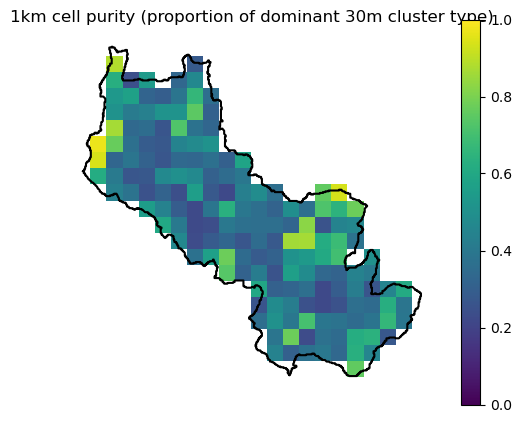

In [29]:
fig, ax = plt.subplots(figsize=(6, 5))
rainfall_gdf_purity.plot(column="dominant_purity", ax=ax, legend=True,
                          cmap="viridis", vmin=0, vmax=1)
catchment_Dolwen.boundary.plot(ax=ax, color="black")
ax.axis('off')
ax.set_title("1km cell purity (proportion of dominant 30m cluster type)")

purity_threshold = 0.5  # e.g. require the cluster to make up ≥60% of the 1km cell

good_zones_for_cluster = {
    cluster_id: proportions.index[proportions[cluster_id] >= purity_threshold].tolist()
    for cluster_id in proportions.columns}

# then when building cluster_candidates, filter to only pixels whose zone_id
# is in good_zones_for_cluster[cluster_id]
good_zones_for_cluster

In [29]:
from scipy.spatial.distance import cdist
import numpy as np

def farthest_point_sampling(
    candidate_indices,
    n_select,
    cell_coords,
    existing_coords,
    min_dist
):
    selected = []
    
    # Combine existing + selected dynamically
    def get_all_selected_coords():
        if len(selected) == 0:
            return existing_coords
        return np.vstack([existing_coords, cell_coords[selected]])

    for _ in range(n_select):
        best_idx = None
        best_dist = -np.inf

        for idx in candidate_indices:
            if idx in selected:
                continue

            candidate_xy = cell_coords[idx]

            # Enforce minimum distance constraint
            if not is_feasible(candidate_xy, selected, cell_coords, existing_coords, min_dist):
                continue

            # Distance to ALL existing + selected points
            all_coords = get_all_selected_coords()
            dists = cdist([candidate_xy], all_coords).flatten()

            # We maximise the MIN distance (maximin design)
            min_dist_to_set = dists.min()

            if min_dist_to_set > best_dist:
                best_dist = min_dist_to_set
                best_idx = idx

        if best_idx is None:
            break  # no feasible points left

        selected.append(best_idx)

    return selected

def fps_with_cluster_quota(
    cluster_candidates,
    cluster_counts,
    cell_coords,
    existing_coords,
    min_dist
):
    selected = {c: [] for c in cluster_candidates}
    selected_idx = []

    # Flatten all candidates
    all_candidates = [
        (c, idx)
        for c, idxs in cluster_candidates.items()
        for idx in idxs
    ]

    remaining_quota = cluster_counts.copy()

    while remaining_quota.sum() > 0:
        best = None
        best_dist = -np.inf

        for c, idx in all_candidates:
            if remaining_quota[c] <= 0:
                continue
            if idx in selected_idx:
                continue

            candidate_xy = cell_coords[idx]

            if not is_feasible(candidate_xy, selected_idx, cell_coords, existing_coords, min_dist):
                continue

            if len(selected_idx) == 0:
                d = cdist([candidate_xy], existing_coords).min()
            else:
                d = cdist([candidate_xy], np.vstack([existing_coords, cell_coords[selected_idx]])).min()

            if d > best_dist:
                best = (c, idx)
                best_dist = d

        if best is None:
            break

        c, idx = best
        selected[c].append(idx)
        selected_idx.append(idx)
        remaining_quota[c] -= 1

    return selected


from scipy.spatial.distance import cdist
import numpy as np
import pandas as pd

def fps_with_cluster_quota(
    cluster_candidates,
    cluster_counts,
    cell_coords,
    existing_coords,
    X,  # <-- scaled feature space (IMPORTANT)
    min_dist,
    w_spatial=1.0,
    w_feature=1.0
):
    selected = {c: [] for c in cluster_candidates}
    selected_idx = []

    # Flatten candidates into (cluster_id, index)
    all_candidates = [
        (c, idx)
        for c, idxs in cluster_candidates.items()
        for idx in idxs
    ]

    remaining_quota = cluster_counts.copy()

    while remaining_quota.sum() > 0:
        best = None
        best_score = -np.inf

        for c, idx in all_candidates:
            # Skip if cluster quota filled
            if remaining_quota[c] <= 0:
                continue

            # Skip if already selected
            if idx in selected_idx:
                continue

            candidate_xy = cell_coords[idx]
            candidate_feat = X[idx]

            # Enforce minimum distance constraint
            if not is_feasible(candidate_xy, selected_idx, cell_coords, existing_coords, min_dist):
                continue

            # -----------------------------
            # Spatial distance
            # -----------------------------
            if len(selected_idx) == 0:
                spatial_dist = cdist([candidate_xy], existing_coords).min()
            else:
                all_xy = np.vstack([existing_coords, cell_coords[selected_idx]])
                spatial_dist = cdist([candidate_xy], all_xy).min()

            # -----------------------------
            # Feature distance (scaled space)
            # -----------------------------
            if len(selected_idx) == 0:
                feature_dist = 0  # no comparison yet
            else:
                selected_feats = X[selected_idx]
                feature_dist = cdist([candidate_feat], selected_feats).min()

            # -----------------------------
            # Combined score
            # -----------------------------
            # score = w_spatial * spatial_dist + w_feature * feature_dist

            spatial_scaled = spatial_dist / 1000.0  # metres → km
            score = w_spatial * spatial_scaled + w_feature * feature_dist
            
            if score > best_score:
                best = (c, idx)
                best_score = score

        if best is None:
            break  # no feasible candidates left

        c, idx = best
        selected[c].append(idx)
        selected_idx.append(idx)
        remaining_quota[c] -= 1

    return selected

   cluster   row   col              x              y         dem      slope
0        0  3190  2768  295367.500031  279622.499886  281.239990   6.224811
1        1  2234  3429  298672.500030  284402.499885  283.570007   8.136529
2        1  1818  2461  293832.500032  286482.499884  270.959991   7.872779
3        2  3933  2507  294062.500032  275907.499887  427.880005   9.149440
4        2  2565  1939  291222.500033  282747.499885  421.750000   8.904057
5        3   765   489  283972.500035  291747.499882  438.130005   8.034526
6        4   252  1403  288542.500033  294312.499882  322.779999   7.136067
7        6  3382  2072  291887.500032  278662.499886  473.260010   8.766512
8        8  1924  1264  287847.500034  285952.499884  322.350006  22.552662
9        9  2593  1418  288617.500033  282607.499885  340.880005  25.487535


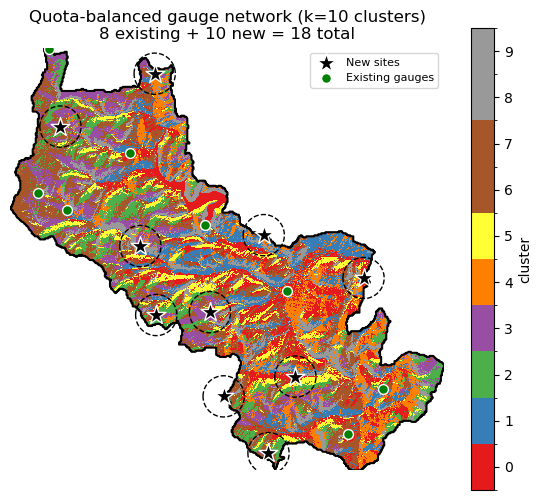

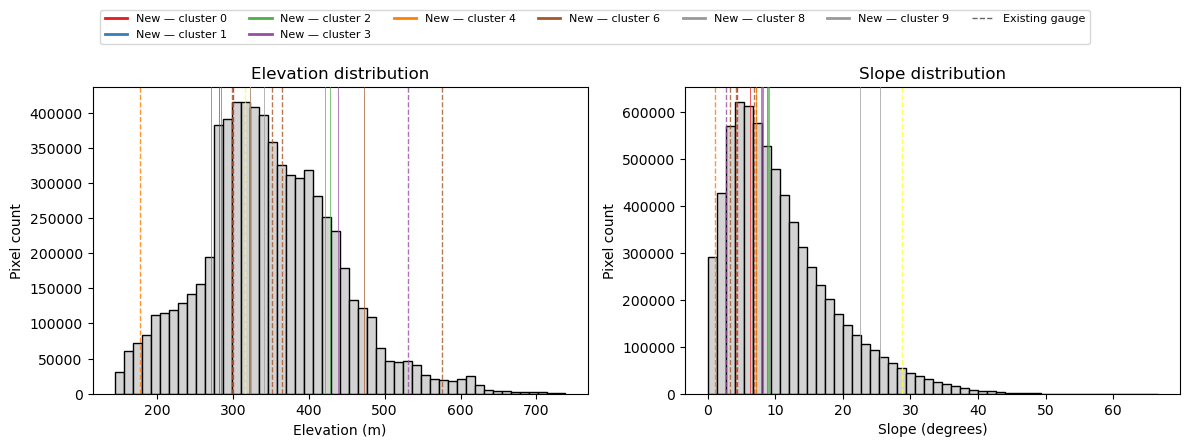

In [61]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import importlib
import rioxarray
import rasterio
import matplotlib.colors as mcolors
import matplotlib
import random
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

data_dir = "/scratch/hydro4/users/kv25483/FDRI/Rain_gauge_optimisation/Data/"
catchment_Dolwen = gpd.read_file(data_dir + "54080/54080.shp")

import functions
importlib.reload(functions)
from functions import *   # expects: is_feasible, greedy_selection, shuffle_greedy, score

# --------------------------------------------------
# Load rain gauge metadata (existing network)
# --------------------------------------------------
rain_meta_cmd = pd.read_csv(data_dir + "rain_meta_for_CMD.csv")
rain_meta_sf = gpd.GeoDataFrame( rain_meta_cmd, geometry=gpd.points_from_xy(rain_meta_cmd["x_2"], rain_meta_cmd["y_2"]),
    crs="EPSG:27700")

rainfall_gdf_merged = gpd.read_file(data_dir + "Derived/rainfall_gdf_merged.gpkg")

# --------------------------------------------------
# 1. Load DEM
# --------------------------------------------------
dem_path = data_dir + "dem_Dolwen.tif"
with rioxarray.open_rasterio(dem_path, masked=True) as dem_rx:
    dem = dem_rx.squeeze()
    dem_arr = dem.values.astype(float)
    transform = dem.rio.transform()

dx = transform.a
dy = -transform.e

# --------------------------------------------------
# 2. Slope + aspect
# --------------------------------------------------
dz_dy, dz_dx = np.gradient(dem_arr, dy, dx)
slope_arr = np.degrees(np.arctan(np.sqrt(dz_dx**2 + dz_dy**2)))
aspect_arr = np.degrees(np.arctan2(-dz_dx, dz_dy))
aspect_arr = np.where(aspect_arr < 0, 360 + aspect_arr, aspect_arr)

aspect_rad = np.deg2rad(aspect_arr)
aspect_sin = np.sin(aspect_rad)
aspect_cos = np.cos(aspect_rad)

# --------------------------------------------------
# 3. Valid pixel mask + feature matrix
#    (using dem + slope only, matching your latest script;
#     add aspect_sin/aspect_cos back in here AND in gauge_features
#     below if you want aspect included)
# --------------------------------------------------
valid_mask = ~np.isnan(dem_arr) & ~np.isnan(slope_arr) & ~np.isnan(aspect_arr)

features = np.column_stack([dem_arr[valid_mask],
                            slope_arr[valid_mask],
                           aspect_sin[valid_mask],
                         aspect_cos[valid_mask],
                           ])

# --------------------------------------------------
# 4. Scale + cluster
# --------------------------------------------------
scaler = StandardScaler()
X = scaler.fit_transform(features)

k = 10
kmeans = KMeans(n_clusters=k, random_state=0)
labels = kmeans.fit_predict(X)

# --------------------------------------------------
# 5. Reshape labels back into 2D grid
# --------------------------------------------------
label_grid = np.full(dem_arr.shape, np.nan)
label_grid[valid_mask] = labels

label_xr = dem.copy()
label_xr.data = label_grid

# --------------------------------------------------
# 6. Cluster colormap (reused across all plots)
# --------------------------------------------------
cmap = matplotlib.colormaps["Set1"].resampled(k)
bounds = np.arange(-0.5, k, 1)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# fig, ax = plt.subplots(figsize=(6, 5))
# label_xr.plot(ax=ax, cmap=cmap, norm=norm, add_colorbar=True,
#               cbar_kwargs={"ticks": np.arange(k), "label": "cluster"})
# catchment_Dolwen.boundary.plot(ax=ax, color="black")
# ax.axis('off')
# ax.set_title(f'K-means clusters (k={k}), native resolution')

# --------------------------------------------------
# 7. Candidate lists per cluster + array-based cell_coords
# --------------------------------------------------
N_CANDIDATES = 200  # increase if clusters fail to fill (see step 10 output)

valid_rows, valid_cols = np.where(valid_mask)
rep_xs_all, rep_ys_all = rasterio.transform.xy(transform, valid_rows, valid_cols)
cell_coords = np.column_stack([np.array(rep_xs_all), np.array(rep_ys_all)])

cluster_candidates = {}
for cluster_id in range(k):
    cluster_mask = labels == cluster_id
    cluster_points = X[cluster_mask]
    global_indices = np.where(cluster_mask)[0]

    dists = cdist(cluster_points, kmeans.cluster_centers_[cluster_id].reshape(1, -1)).flatten()
    order = np.argsort(dists)
    top_n_global = global_indices[order[:N_CANDIDATES]]

    cluster_candidates[cluster_id] = [int(i) for i in top_n_global]

# --------------------------------------------------
# 8. Assign EXISTING gauges to clusters (same scaler/kmeans as pixels)
# --------------------------------------------------
gauge_xs = rain_meta_sf.geometry.x.values
gauge_ys = rain_meta_sf.geometry.y.values

gauge_rows, gauge_cols = rasterio.transform.rowcol(transform, gauge_xs, gauge_ys)
gauge_rows = np.array(gauge_rows)
gauge_cols = np.array(gauge_cols)

valid_gauge = (
    (gauge_rows >= 0) & (gauge_rows < dem_arr.shape[0]) &
    (gauge_cols >= 0) & (gauge_cols < dem_arr.shape[1]))

if not valid_gauge.all():
    print(f"Warning: {(~valid_gauge).sum()} gauges fall outside DEM extent — check these")

gauge_dem = dem_arr[gauge_rows[valid_gauge], gauge_cols[valid_gauge]]
gauge_slope = slope_arr[gauge_rows[valid_gauge], gauge_cols[valid_gauge]]
gauge_aspect_sin = aspect_sin[gauge_rows[valid_gauge], gauge_cols[valid_gauge]]
gauge_aspect_cos = aspect_cos[gauge_rows[valid_gauge], gauge_cols[valid_gauge]]

gauge_features = np.column_stack([gauge_dem, gauge_slope, gauge_aspect_sin, gauge_aspect_cos])
gauge_X = scaler.transform(gauge_features)
gauge_clusters = kmeans.predict(gauge_X)

rain_meta_sf_valid = rain_meta_sf.loc[valid_gauge].copy()
rain_meta_sf_valid["cluster"] = gauge_clusters

existing_counts = rain_meta_sf_valid["cluster"].value_counts().reindex(range(k), fill_value=0)
# print("Existing gauges per cluster:\n", existing_counts)

# --------------------------------------------------
# 9. Quota per cluster (pixel-population-weighted) + new gauges needed
# --------------------------------------------------
n_total_final = 18
n_new = 10

cluster_sizes = pd.Series(labels).value_counts().reindex(range(k), fill_value=0)
quota_fraction = cluster_sizes / cluster_sizes.sum()
target_quota = quota_fraction * n_total_final

new_needed = pd.Series(0, index=range(k))
for _ in range(n_new):
    current_total = existing_counts + new_needed
    gap = target_quota - current_total
    target_cluster = gap.idxmax()
    new_needed[target_cluster] += 1

# print("Target quota per cluster:\n", target_quota.round(2))
# print("New gauges to place per cluster:\n", new_needed)
# assert new_needed.sum() == n_new

# --------------------------------------------------
# 10. Greedy multi-site selection with min_dist constraint
#     (vs. existing gauges AND vs. previously chosen new sites)
# --------------------------------------------------
existing_coords = np.column_stack([gauge_xs[valid_gauge], gauge_ys[valid_gauge]])
min_dist = 1000  # metres

# solution_multi = fps_with_cluster_quota(cluster_candidates,new_needed,cell_coords,existing_coords,min_dist)

solution_multi = fps_with_cluster_quota(
    cluster_candidates,
    new_needed,
    cell_coords,
    existing_coords,
    X,                 # <-- scaled features
    min_dist,
    w_spatial=1.0,
    w_feature=5.0      # <-- usually want feature space to matter more
)


if failed_multi:
    print("Under-filled clusters (increase N_CANDIDATES if this happens):", failed_multi)

# --------------------------------------------------
# 11. Flatten selection into a DataFrame
# --------------------------------------------------
selected_records = []
for cluster_id, idx_list in solution_multi.items():
    for idx in idx_list:
        row, col = valid_rows[idx], valid_cols[idx]
        x, y = cell_coords[idx]
        selected_records.append({
            "cluster": cluster_id, "row": row, "col": col, "x": x, "y": y,
            "dem": dem_arr[row, col], "slope": slope_arr[row, col],})

selected_df = pd.DataFrame(selected_records)
print(selected_df)

# --------------------------------------------------
# 12. Buffers around new sites + full network plot
# --------------------------------------------------
selected_gdf = gpd.GeoDataFrame(
    selected_df, geometry=gpd.points_from_xy(selected_df["x"], selected_df["y"]), crs="EPSG:27700")

buffer_gdf = selected_gdf.copy()
buffer_gdf["geometry"] = selected_gdf.geometry.buffer(min_dist)

fig, ax = plt.subplots(figsize=(7, 6))
label_xr.plot(ax=ax, cmap=cmap, norm=norm, add_colorbar=True,
              cbar_kwargs={"ticks": np.arange(k), "label": "cluster"})
catchment_Dolwen.boundary.plot(ax=ax, color="black")

buffer_gdf.boundary.plot(ax=ax, color="black", linestyle="--", linewidth=1)
ax.scatter(selected_df["x"], selected_df["y"], c="black", edgecolor="white",
           s=200, marker="*", zorder=5, label="New sites")
rain_meta_sf_valid.plot(ax=ax, color="green", marker=".", markersize=200,
                         edgecolor="white", zorder=5, label="Existing gauges")

ax.axis('off')
ax.legend(loc="upper right", fontsize=8)
ax.set_title(
    f'Quota-balanced gauge network (k={k} clusters)\n'
    f'{existing_counts.sum()} existing + {new_needed.sum()} new = '
    f'{existing_counts.sum() + new_needed.sum()} total')

# --------------------------------------------------
# 13. Distribution check — where do new + existing gauges fall
#     relative to the full catchment DEM/slope distributions
# --------------------------------------------------
fig, axs = plt.subplots(ncols=2, figsize=(12, 4))

# ---- Elevation ----
axs[0].hist(dem_arr[valid_mask], bins=50, color="lightgray", edgecolor="black", zorder=1)

# new sites: solid line, coloured by cluster
for _, row in selected_df.iterrows():
    axs[0].axvline(row["dem"], color=cmap(row["cluster"] / (k - 1)),
                    linewidth=0.5, linestyle="-", zorder=3)

# existing gauges: dashed grey/black line, distinct from cluster colours
for val, cluster in zip(gauge_dem, gauge_clusters):
    axs[0].axvline(val,color=cmap(cluster / (k - 1)),linewidth=1,linestyle="--",alpha=0.8,zorder=2)

axs[0].set_xlabel("Elevation (m)")
axs[0].set_ylabel("Pixel count")
axs[0].set_title("Elevation distribution")


# ---- Slope ----
axs[1].hist(slope_arr[valid_mask], bins=50, color="lightgray", edgecolor="black", zorder=1)

for _, row in selected_df.iterrows():
    axs[1].axvline(row["slope"], color=cmap(row["cluster"] / (k - 1)),
                    linewidth=0.5, linestyle="-", zorder=3)

# ---- Slope ----
for val, cluster in zip(gauge_slope, gauge_clusters):
    axs[1].axvline(val,color=cmap(cluster / (k - 1)),linewidth=1,linestyle="--",alpha=0.8,zorder=2)

axs[1].set_xlabel("Slope (degrees)")
axs[1].set_ylabel("Pixel count")
axs[1].set_title("Slope distribution")

# --------------------------------------------------
# Shared legend: cluster colours for new sites + one entry for existing
# --------------------------------------------------
from matplotlib.lines import Line2D

cluster_handles = [
    Line2D([0], [0], color=cmap(c / (k - 1)), lw=2, label=f"New — cluster {c}")
    for c in sorted(selected_df["cluster"].unique())]
existing_handle = Line2D([0], [0], color="black", lw=1, linestyle="--", alpha=0.6, label="Existing gauge")

fig.legend(handles=cluster_handles + [existing_handle],
           loc="upper center", ncol=min(len(cluster_handles) + 1, 7),
           bbox_to_anchor=(0.5, 1.12), fontsize=8)

plt.tight_layout()

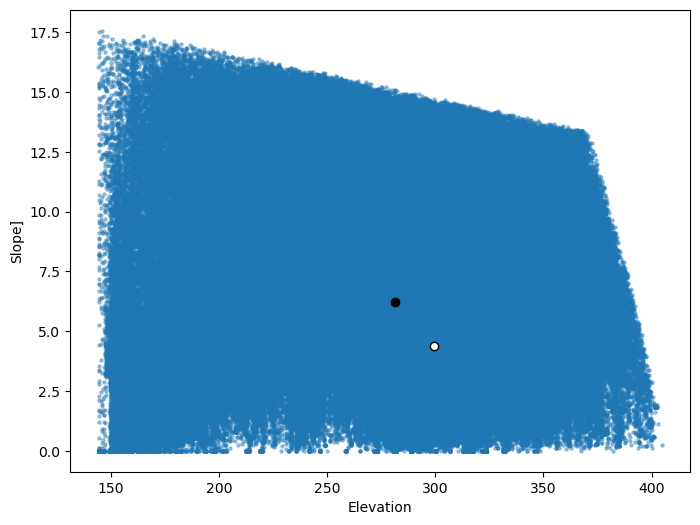

In [62]:
fig, ax = plt.subplots(figsize=(8,6))
cluster_id = 0

# Create dataframe of the original (unscaled) features
cluster_plot_df = pd.DataFrame({"Elevation": features[:, 0],"Slope": features[:, 1],"Cluster": labels})

this_cluster = cluster_plot_df[cluster_plot_df['Cluster']==cluster_id]
scatter = ax.scatter(this_cluster["Elevation"],this_cluster["Slope"],s=5,alpha=0.4)

ax.set_xlabel('Elevation')
ax.set_ylabel('Slope]')

cluster_mask = labels == cluster_id

dem_vals = features[cluster_mask][:, 0]
slope_vals = features[cluster_mask][:, 1]

cluster_selected = selected_df[selected_df["cluster"] == cluster_id]
for _, row in cluster_selected.iterrows():
    ax.scatter(row["dem"],row["slope"],color='black')
    
for dem, slope, g_cluster in zip(gauge_dem, gauge_slope, gauge_clusters):
    if g_cluster == cluster_id:

        ax.scatter(dem,slope, color = 'white', edgecolor='black', marker = 'o')        

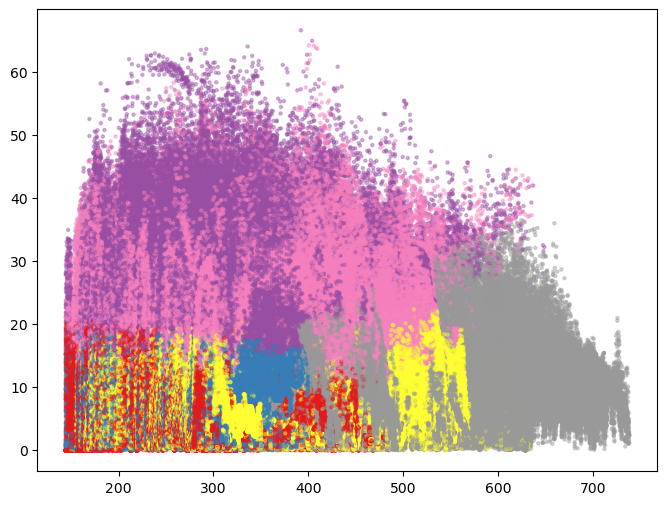

In [26]:
# Create dataframe of the original (unscaled) features
cluster_plot_df = pd.DataFrame({
    "Elevation": features[:, 0],
    "Slope": features[:, 1],
    "Cluster": labels})

fig, ax = plt.subplots(figsize=(8,6))

scatter = ax.scatter(cluster_plot_df["Elevation"],cluster_plot_df["Slope"],c=cluster_plot_df["Cluster"],cmap="Set1",
                     s=5,alpha=0.4)

ax.set_xlabel('Elevation')
ax.set_ylabel('Slope]')

# Plot cluster centres (convert back from scaled space)
# centres = scaler.inverse_transform(kmeans.cluster_centers_)

# ax.scatter(
#     centres[:,0],
#     centres[:,1],
#     c="black",
#     s=150,
#     marker="X",
#     edgecolor="white",
#     linewidth=1,
#     label="Cluster centres"
# )

# for i, (x,y) in enumerate(centres):
#     ax.text(
#         x, y, f" {i}",
#         fontsize=12,
#         weight="bold"
#     )

# ax.set_xlabel("Elevation (m)")
# ax.set_ylabel("Slope (degrees)")
# ax.set_title("Terrain clusters in elevation-slope space")

# plt.colorbar(scatter, ax=ax, label="Cluster")
# ax.legend()
# plt.show()

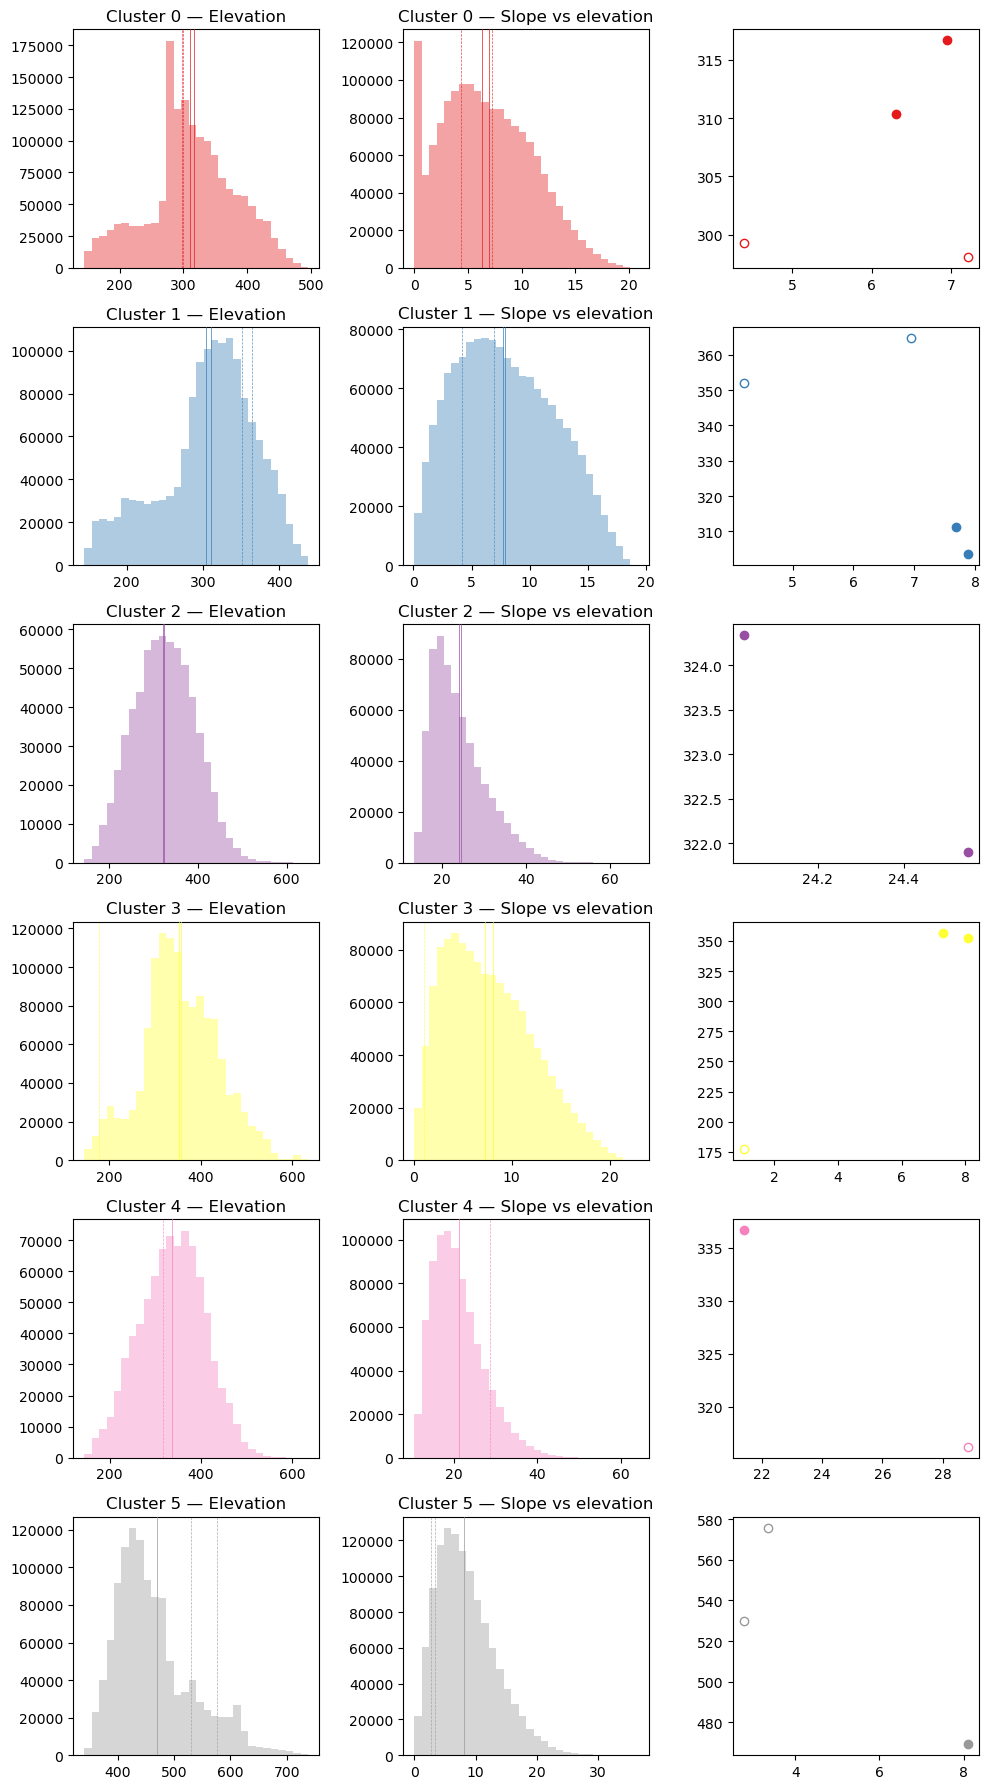

In [40]:
features = np.column_stack([
    dem_arr[valid_mask],
    slope_arr[valid_mask],])

fig, axs = plt.subplots(nrows=k, ncols=3, figsize=(10, 3*k))

for cluster_id in range(k):
    cluster_mask = labels == cluster_id

    dem_vals = features[cluster_mask][:, 0]
    slope_vals = features[cluster_mask][:, 1]

    # ----------------------------
    # Histograms (cluster background)
    # ----------------------------
    axs[cluster_id, 0].hist(dem_vals, bins=30,color=cmap(cluster_id / (k - 1)), alpha=0.4)

    axs[cluster_id, 1].hist(slope_vals, bins=30,color=cmap(cluster_id / (k - 1)), alpha=0.4)

    # ----------------------------
    # Suggested gauges (solid)
    # ----------------------------
    cluster_selected = selected_df[selected_df["cluster"] == cluster_id]

    for _, row in cluster_selected.iterrows():
        axs[cluster_id, 0].axvline(row["dem"],color=cmap(cluster_id / (k - 1)),linewidth=0.5,linestyle="-",zorder=3)

        axs[cluster_id, 1].axvline(row["slope"],color=cmap(cluster_id / (k - 1)),linewidth=0.5,linestyle="-",zorder=3)

        axs[cluster_id, 2].scatter(row["slope"],row["dem"],color=cmap(cluster_id / (k - 1)))
        
    # ----------------------------
    # Existing gauges (dashed)
    # ----------------------------
    for dem, slope, g_cluster in zip(gauge_dem, gauge_slope, gauge_clusters):
        if g_cluster == cluster_id:
            axs[cluster_id, 0].axvline(dem, color=cmap(cluster_id / (k - 1)), linewidth=0.5, linestyle="--", alpha=0.8, 
                                       zorder=2)

            axs[cluster_id, 1].axvline(slope,color=cmap(cluster_id / (k - 1)),linewidth=0.5,linestyle="--",alpha=0.8,zorder=2)
            
            axs[cluster_id, 2].scatter(slope,dem, color = 'white', edgecolor=cmap(cluster_id / (k - 1)), marker = 'o')
    # ----------------------------
    # Labels
    # ----------------------------
    axs[cluster_id, 0].set_title(f"Cluster {cluster_id} — Elevation")
    axs[cluster_id, 1].set_title(f"Cluster {cluster_id} — Slope")
    axs[cluster_id, 1].set_title(f"Cluster {cluster_id} — Slope vs elevation")

plt.tight_layout()